In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [ ]:
base_path = r'C:\Users\haruka\Desktop\AI수업\mcp-month-2\data'

In [3]:
file_path = os.path.join(base_path, 'fish.csv')
fish_df = pd.read_csv(file_path)

In [4]:
perch_length = fish_df[fish_df.Species == 'Perch']['Length'].values
perch_weight = fish_df[fish_df.Species == 'Perch']['Weight'].values

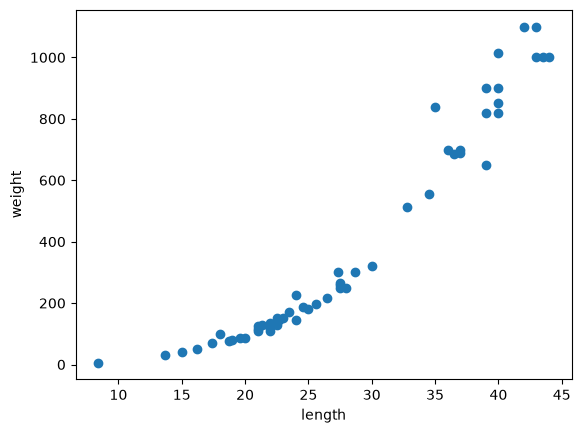

In [5]:
plt.scatter(perch_length, perch_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target=\
train_test_split(perch_length, perch_weight, random_state=42)

In [8]:
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

In [9]:
from sklearn.neighbors import KNeighborsRegressor

In [10]:
knr = KNeighborsRegressor()

In [11]:
knr.fit(train_input, train_target);

In [12]:
knr.score(test_input, test_target)

0.992809406101064

In [13]:
knr.score(train_input, train_target)

0.9698823289099254

In [14]:
knr.n_neighbors = 3

In [15]:
knr.fit(train_input, train_target)
print(knr.score(train_input, train_target))

0.9804899950518966


In [16]:
knr.score(test_input, test_target)

0.9746459963987609

In [17]:
knr = KNeighborsRegressor()
x = np.arange(5, 45).reshape(-1, 1)

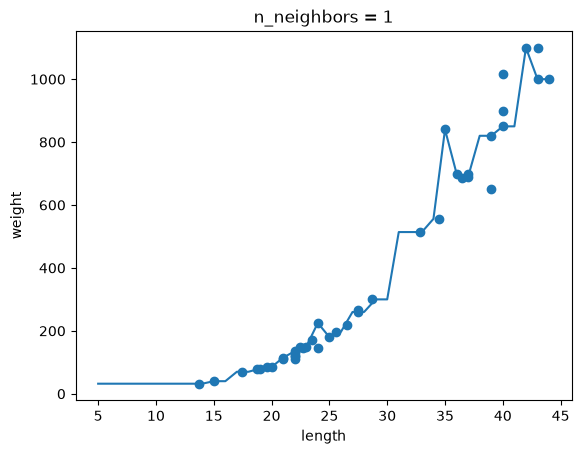

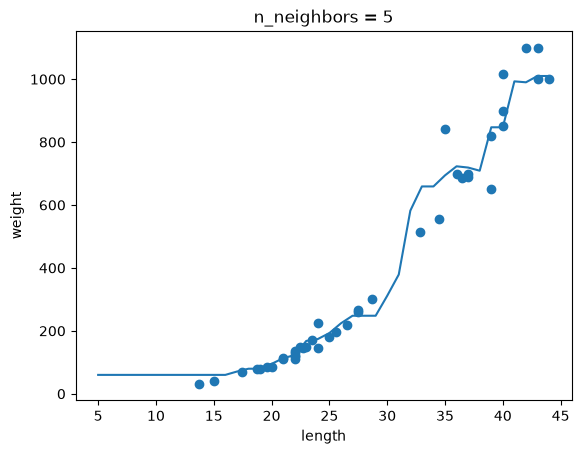

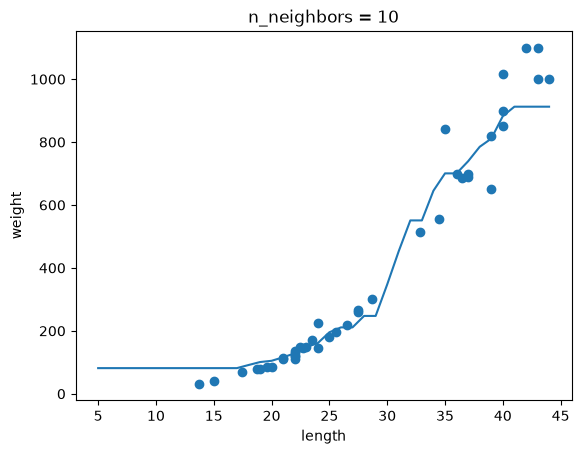

In [18]:
for n in [1, 5, 10]:
  knr.n_neighbors = n
  knr.fit(train_input, train_target)
  prediction = knr.predict(x)
  
  plt.scatter(train_input, train_target)
  plt.plot(x, prediction)
  
  plt.title('n_neighbors = {}'.format(n))
  plt.xlabel('length')
  plt.ylabel('weight')
  plt.show()

In [19]:
knr = KNeighborsRegressor(n_neighbors=3)
knr.fit(train_input, train_target);

In [20]:
print(knr.predict([[50]]))

[1033.33333333]


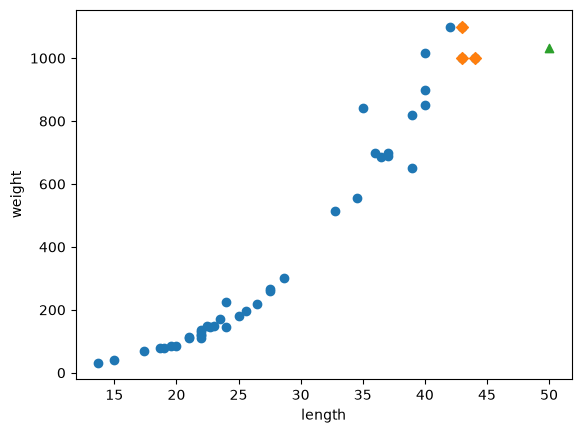

In [22]:
distances, indexes = knr.kneighbors([[50]])

plt.scatter(train_input, train_target)
plt.scatter(train_input[indexes], train_target[indexes], marker='D')
plt.scatter(50, 1033.33333, marker='^')

plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [23]:
from sklearn.linear_model import LinearRegression

In [25]:
lr = LinearRegression()
lr.fit(train_input, train_target);

In [26]:
print(lr.predict([[50]]))

[1241.83860323]


In [27]:
print(lr.coef_)

[39.01714496]


In [28]:
print(lr.intercept_)

-709.0186449535474


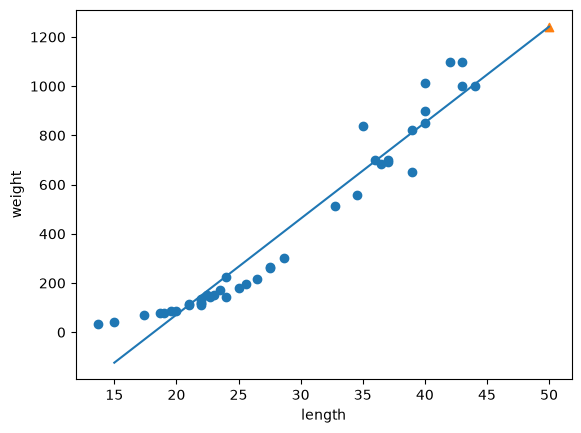

In [29]:
plt.scatter(train_input, train_target)
plt.plot([15, 50], [15 * lr.coef_ + lr.intercept_, 50 * lr.coef_ + lr.intercept_ ])
plt.scatter(50, 1241.8, marker='^')

plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [30]:
print(lr.score(train_input, train_target))
print(lr.score(test_input, test_target))

0.9398463339976041
0.824750312331356


In [31]:
train_poly = np.column_stack((train_input ** 2, train_input))
test_poly = np.column_stack((test_input ** 2, test_input))

In [32]:
lr = LinearRegression()
lr.fit(train_poly, train_target);

In [35]:
print(lr.predict([[2500, 50]]))

[1573.98423528]


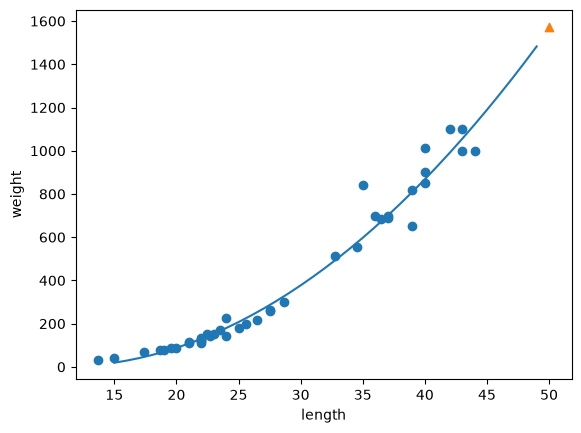

In [36]:
point = np.arange(15, 50)

plt.scatter(train_input, train_target)

plt.plot(point, 1.01 * point ** 2 - 21.6 * point + 116.05)

plt.scatter([50], [1574], marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [37]:
print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))

0.9706807451768623
0.9775935108325122


In [38]:
perch_df = fish_df.loc[fish_df.Species == 'Perch', ['Length', 'Height', 'Width']]

In [39]:
perch_full = perch_df.to_numpy()

In [40]:
train_input, test_input, train_target, test_target=\
train_test_split(perch_full, perch_weight, random_state=42)

In [42]:
from sklearn.preprocessing import PolynomialFeatures

In [43]:
poly = PolynomialFeatures()

In [45]:
poly.fit([[2, 3]]);

In [46]:
print(poly.transform([[2, 3]]))

[[1. 2. 3. 4. 6. 9.]]


In [48]:
poly = PolynomialFeatures(include_bias=False)
poly.fit([[2, 3]])
print(poly.transform([[2, 3]]))

[[2. 3. 4. 6. 9.]]


In [51]:
poly = PolynomialFeatures(include_bias=False)
poly.fit(train_input);

In [52]:
train_poly = poly.transform(train_input)
train_poly.shape # (42, 9)

(42, 9)

In [53]:
poly.get_feature_names_out()

array(['x0', 'x1', 'x2', 'x0^2', 'x0 x1', 'x0 x2', 'x1^2', 'x1 x2',
       'x2^2'], dtype=object)

In [54]:
lr = LinearRegression()
lr.fit(train_poly, train_target)
print(lr.score(train_poly, train_target))

0.9903557670312702


In [55]:
poly = PolynomialFeatures(degree=5, include_bias=False)
poly.fit(train_input)
train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)

print(train_poly.shape)
print(test_poly.shape)

(42, 55)
(14, 55)


In [56]:
from sklearn.preprocessing import StandardScaler

In [58]:
ss = StandardScaler()
ss.fit(train_poly);

In [61]:
train_scaled = ss.transform(train_poly)
test_scaled = ss.transform(test_poly)

In [62]:
from sklearn.linear_model import Ridge

In [63]:
ridge = Ridge()
ridge.fit(train_scaled, train_target)
print(ridge.score(train_scaled, train_target))
print(ridge.score(test_scaled, test_target))

0.9896217956447125
0.9788853860988027


In [64]:
train_score = []
test_score = []

In [65]:
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]

for alpha in alpha_list:
  ridge = Ridge(alpha=alpha)
  ridge.fit(train_scaled, train_target)
  train_score.append(ridge.score(train_scaled, train_target))
  test_score.append(ridge.score(test_scaled, test_target))

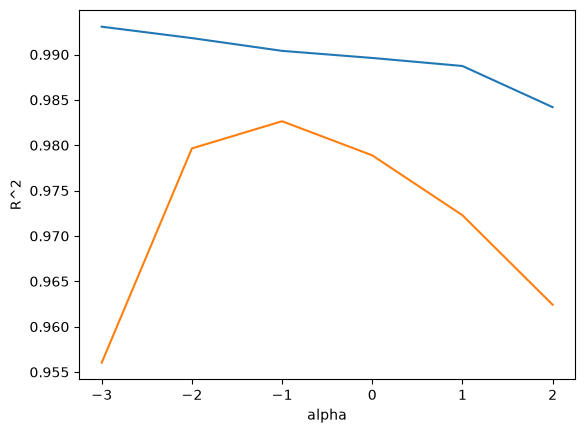

In [67]:
plt.plot(np.log10(alpha_list), train_score)
plt.plot(np.log10(alpha_list), test_score)

plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()

In [70]:
from sklearn.linear_model import Lasso

In [73]:
train_score = []
test_score = []

alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]

for alpha in alpha_list:
  lasso = Lasso(alpha=alpha, max_iter=1000000)
  lasso.fit(train_scaled, train_target)
  train_score.append(lasso.score(train_scaled, train_target))
  test_score.append(lasso.score(test_scaled, test_target))

c:\Users\haruka\Desktop\AI수업\mcp-month-2\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.158790e+03, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(


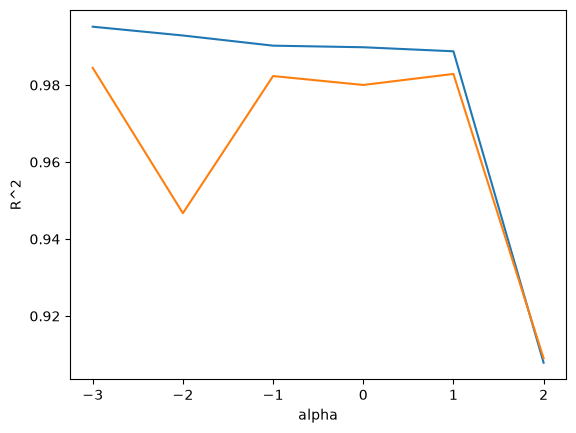

In [74]:
plt.plot(np.log10(alpha_list), train_score)
plt.plot(np.log10(alpha_list), test_score)
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()

In [75]:
lasso = Lasso(alpha=10)
lasso.fit(train_scaled, train_target)

print(lasso.score(train_scaled, train_target)) # 0.9888...
print(lasso.score(test_scaled, test_target)) # 0.9823...

0.988820885788649
0.9823020708550178


In [77]:
print(np.sum(lasso.coef_ == 0))

40
